# Exploratory data analysis of final summary statistics

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
import numpy as np
import missingno as msno

In [3]:
csv = pd.read_csv("/home/maria/git/SOROLLA/SumStats/excell_sumstats_description.csv")

In [4]:
csv.drop(labels="ignore", axis=1, inplace=True)
csv.head()


,type,selection,title,pubmedId,efoTraits,disease,disease_subtype,label,condition_label,summaryStatistics,...,OR,se,p,N_col,N_num,Nca_col,Nca_val,Nco_col,Nco_val,INFO
0,NEU,subtype-family,"Genome-wide meta-analysis, fine-mapping and in...",33589840,alzheimer's disease,alzheimer's disease,family history,alzheimers-disease-family-history,ALZ,http://ftp.ebi.ac.uk/pub/databases/gwas/summar...,...,NaN,standard_error,p_value,NaN,408942,NaN,53042.0,NaN,355900.0,INFO
1,NEU,main,Genetic meta-analysis of diagnosed Alzheimer's...,30820047,late-onset Alzheimers disease,alzheimer's disease,NaN,alzheimers-late-onset-1,ALZ,http://ftp.ebi.ac.uk/pub/databases/gwas/summar...,...,NaN,SE,Pvalue,NaN,63926,NaN,21982.0,NaN,41944.0,NaN
2,NEU,minor,"Meta-analysis of 74,046 individuals identifies...",24162737,Alzheimer disease,alzheimer's disease,NaN,alzheimers-late-onset-4,ALZ,http://ftp.ebi.ac.uk/pub/databases/gwas/summar...,...,NaN,SE,Pvalue,NaN,55134,NaN,17008.0,NaN,37154.0,NaN
3,NEU,main,Common and rare variant association analyses i...,34873335,amyotrophic lateral sclerosis,amyotrophic lateral sclerosis,NaN,lateral-sclerosis-1,SCLE,http://ftp.ebi.ac.uk/pub/databases/gwas/summar...,...,NaN,standard_error,p_value,NaN,138086,NaN,27205.0,NaN,110881.0,NaN
4,NEU,minor,Genome-wide association analyses identify new ...,27455348,amyotrophic lateral sclerosis,amyotrophic lateral sclerosis,NaN,lateral-sclerosis-2,SCLE,http://ftp.ebi.ac.uk/pub/databases/gwas/summar...,...,NaN,standard_error,p_value,NaN,36052,NaN,12577.0,NaN,23475.0,NaN


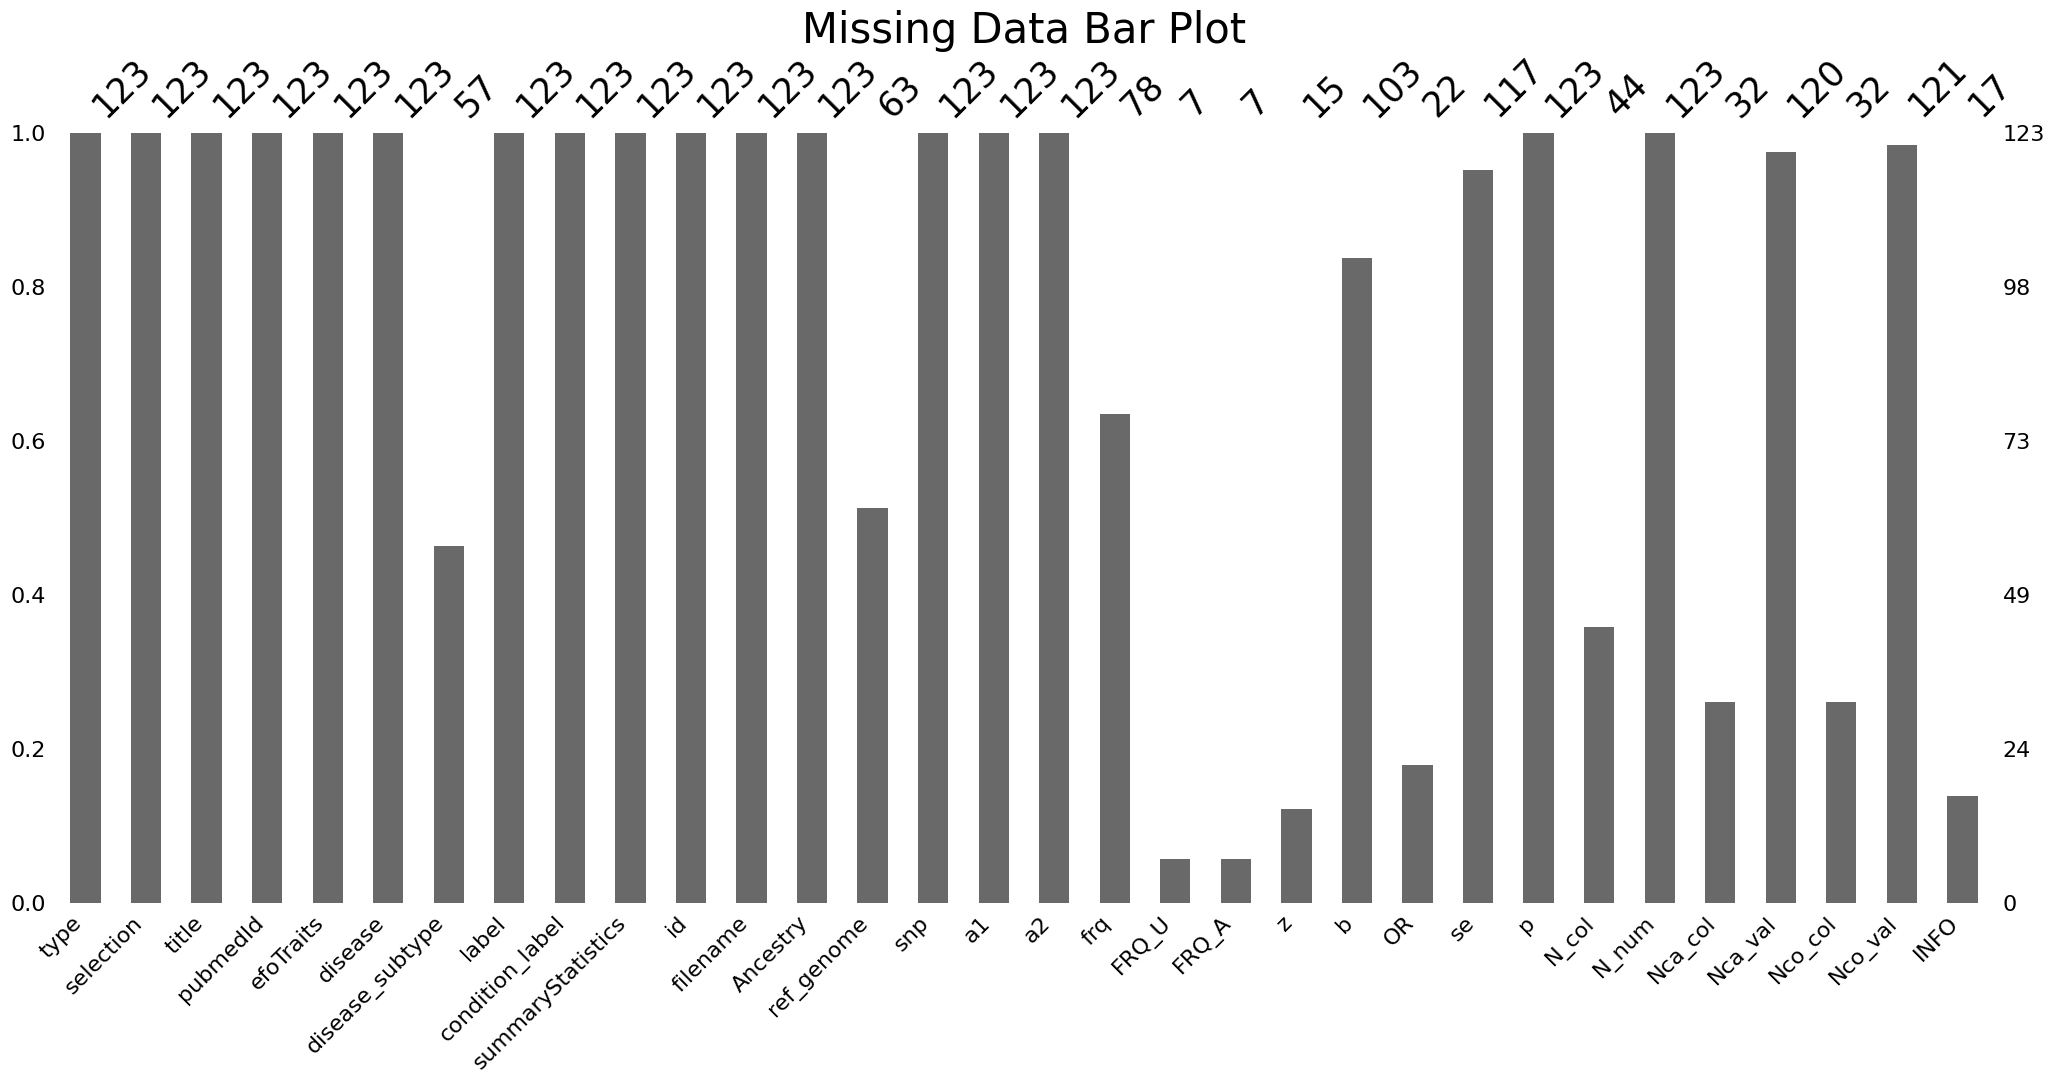

In [14]:
fig, ax = plt.subplots(figsize=(10, 15))

msno.bar(csv)

plt.xticks(fontsize=25) 
plt.yticks(fontsize=25) 
# plt.xlabel('Columns', fontsize=16) 
plt.ylabel('Missing Values Count', fontsize=16)  
plt.title('Missing Data Bar Plot', fontsize=30) 

# Display the plot
plt.show()

<AxesSubplot: >

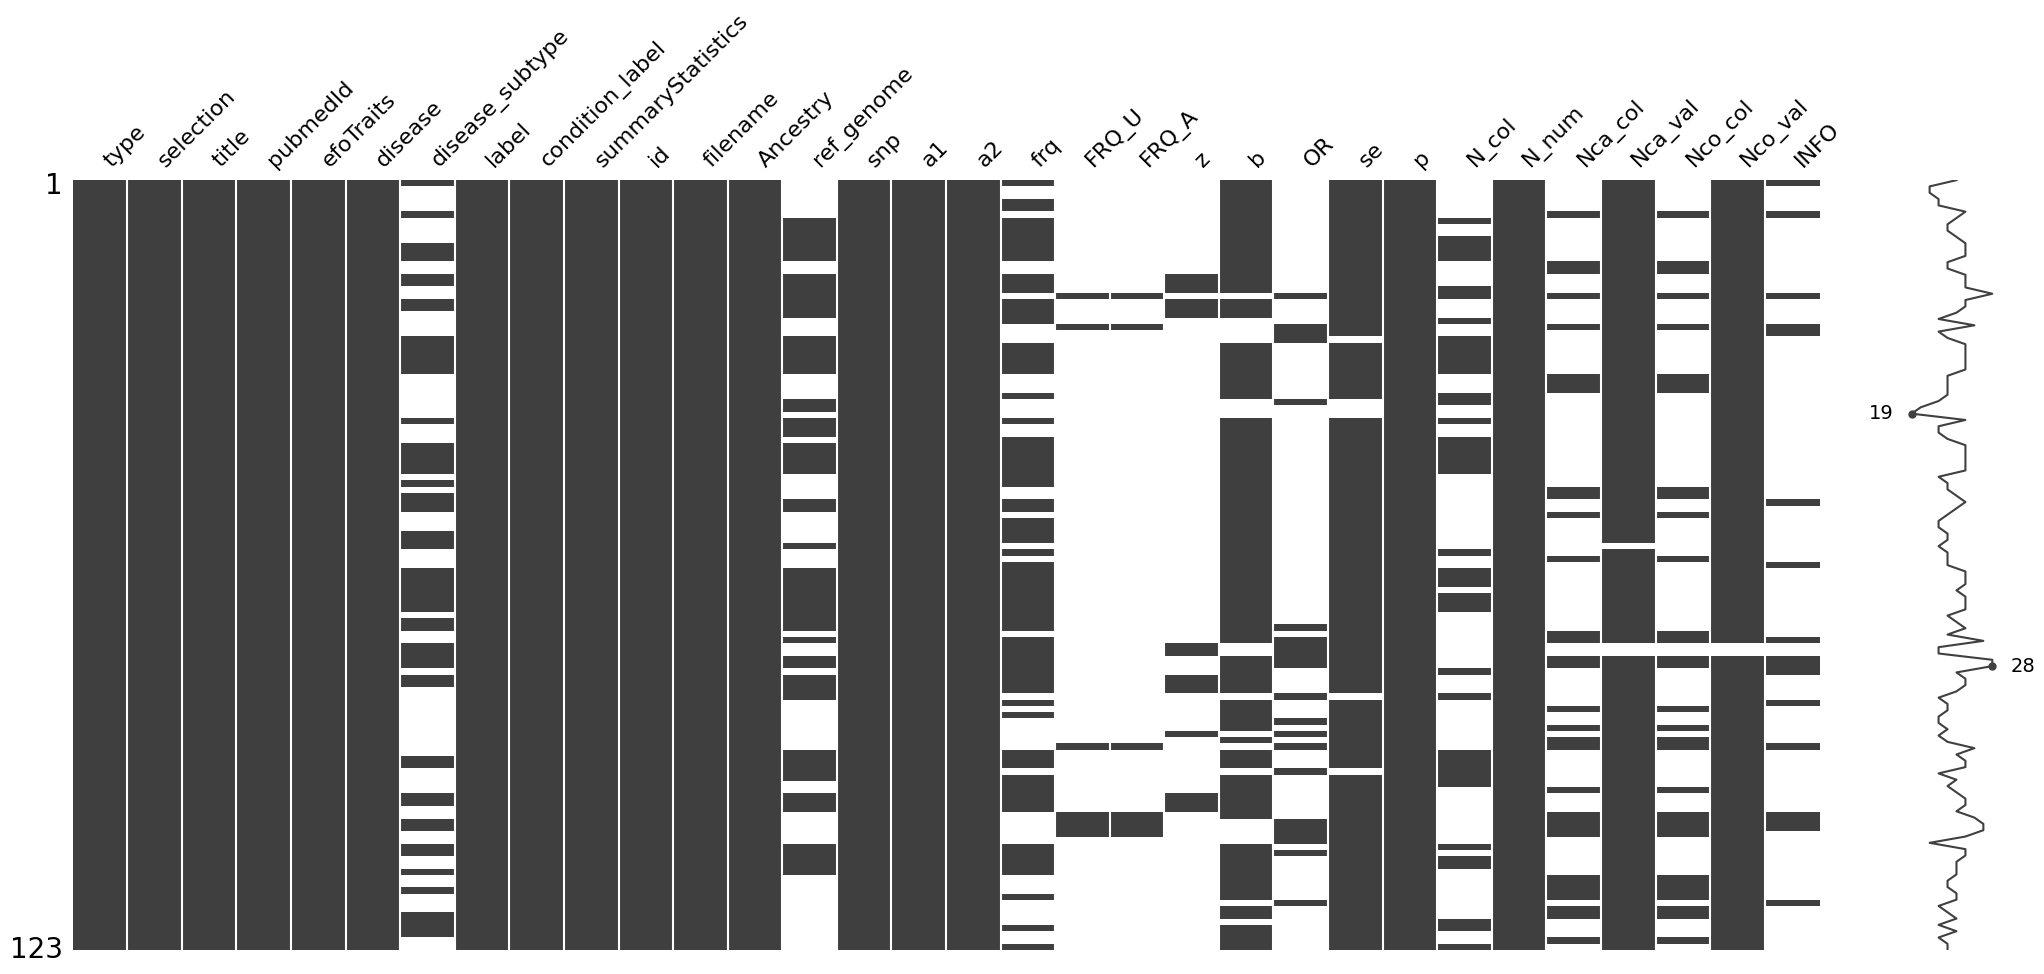

In [6]:
msno.matrix(csv)

In [7]:
csv['N_col'].fillna(value="N_added", inplace=True)
print(csv["N_col"].value_counts())

N_added            79
N                  32
totN                4
n                   3
N_col               2
N-col               2
TotalSampleSize     1
Name: N_col, dtype: int64


In [27]:
type_palette = {"CAN":"#FE6401", "PSY":"#6401FE","NEU":"#01FE64"}

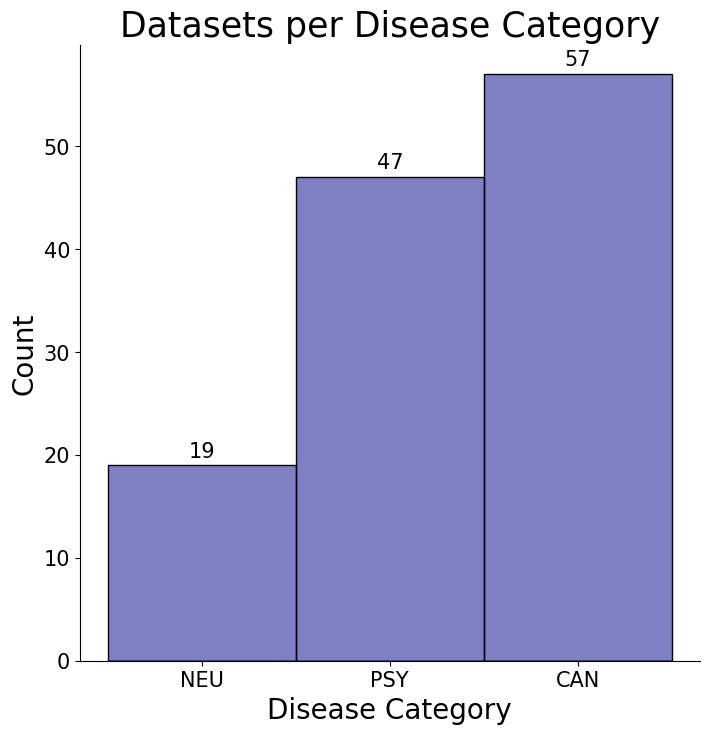

In [23]:
fig, ax = plt.subplots(figsize=(8, 8))

a = sns.histplot(csv, x = "type", hue = "type", palette=['darkblue']*len(csv['type'].unique()), legend=None, ax=ax)
for container in a.containers:
    labels = [f'{height:.0f}' if height > 0 else '' for height in container.datavalues]
    a.bar_label(container, labels=labels, label_type="edge", padding=3, fontsize=15)

sns.despine()

plt.xticks(fontsize=15) 
plt.yticks(fontsize=15) 
plt.xlabel('Disease Category', fontsize=20) 
plt.ylabel('Count', fontsize=20)  
plt.title('Datasets per Disease Category', fontsize=25) 

# Display the plot
plt.show()

In [10]:
print(f"The number of unique diseases in the dataset is", len(csv["disease"].unique()))
print(f"The number of unique pubmedIds in the dataset is", len(csv["pubmedId"].unique()))

The number of unique diseases in the dataset is 38
The number of unique pubmedIds in the dataset is 41


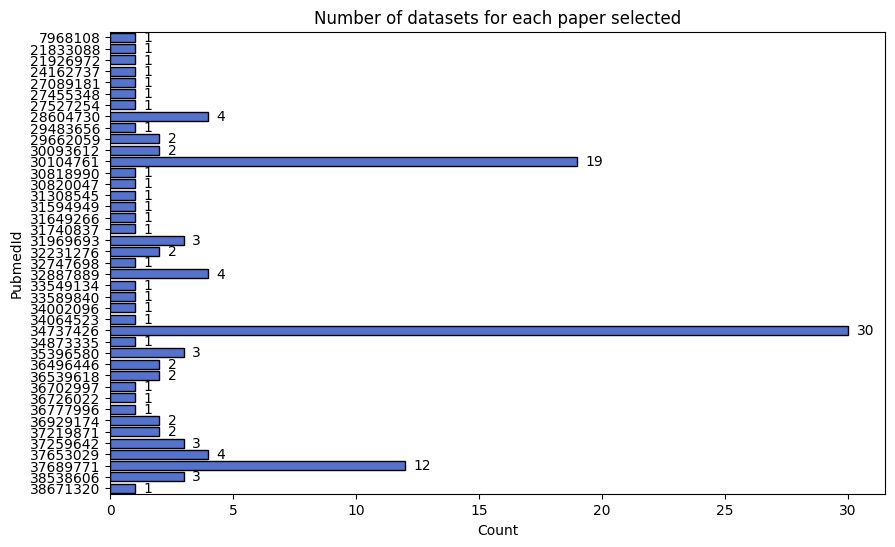

In [11]:
plt.figure(figsize=(10, 6))
a = sns.countplot(y='pubmedId', data=csv, color="royalblue", linewidth=1, edgecolor='black', dodge=True)

for container in a.containers:
    labels = [f'{height:.0f}' if height > 0 else '' for height in container.datavalues]
    a.bar_label(container, labels=labels, label_type="edge", padding=6)
    
plt.xlabel('Count')
plt.ylabel('PubmedId')
plt.title('Number of datasets for each paper selected')
plt.show()


In [25]:
# Calculate the counts of each disease category and sort them
disease_counts = csv['disease'].value_counts().sort_values(ascending=False)
sorted_disease_order = disease_counts.index

Text(0.5, 1.0, 'Distribution datasets per unique Disease')

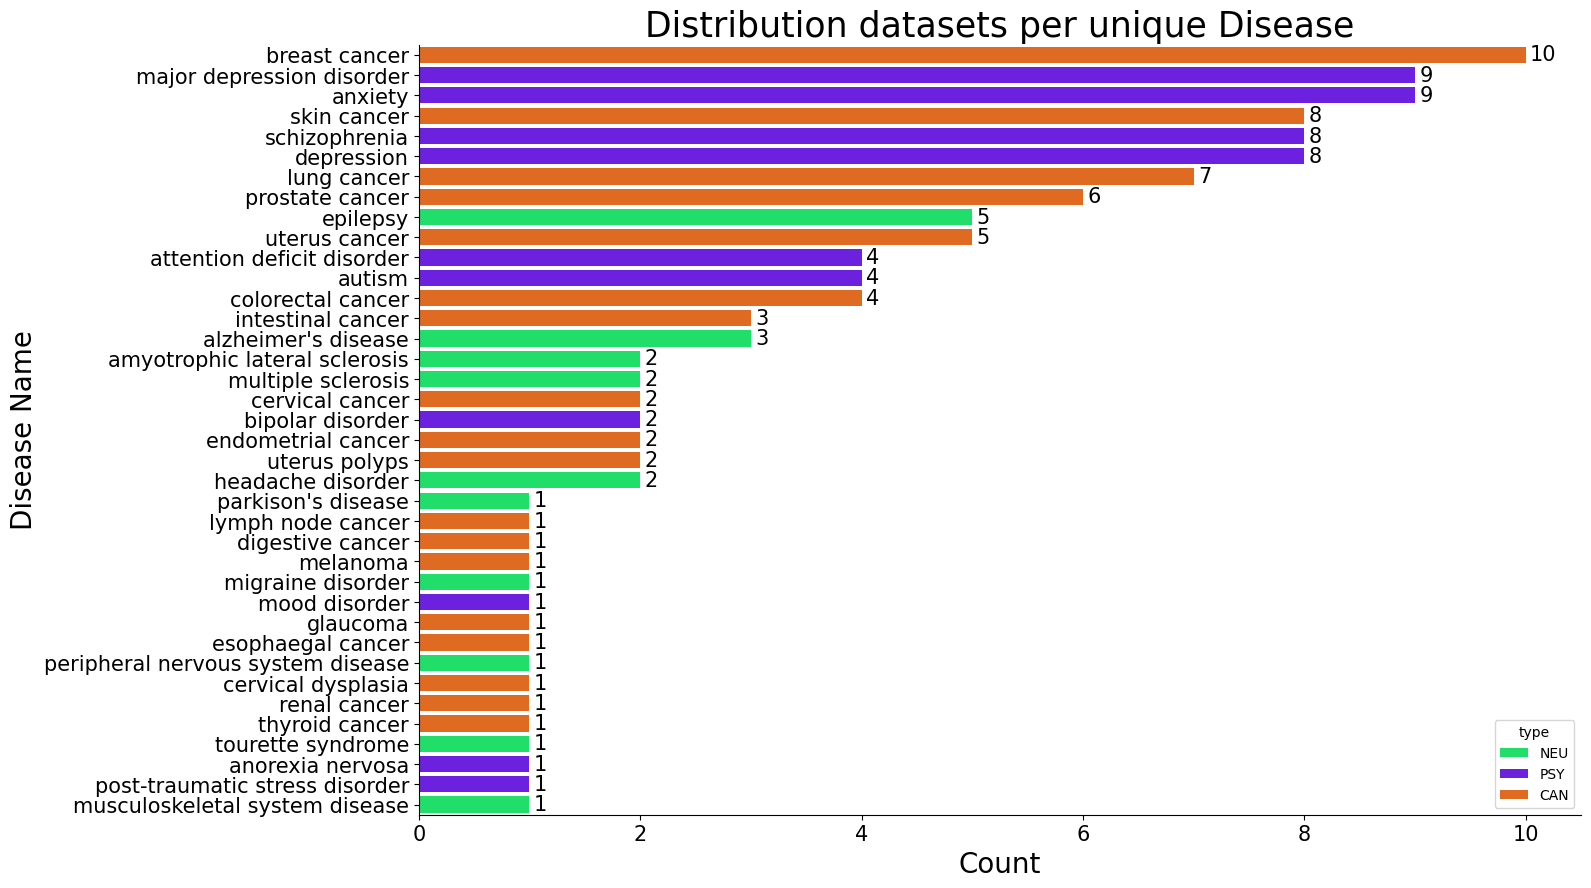

In [33]:
fig, ax = plt.subplots(figsize=(15, 10))
sns.countplot(data=csv, y='disease', hue='type', order=sorted_disease_order, palette=type_palette, ax=ax, dodge=False)

for container in ax.containers:
    labels = [f'{int(height)}' if height > 0 else '' for height in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='edge', padding=3, fontsize=15)


sns.despine()

plt.xticks(fontsize=15) 
plt.yticks(fontsize=15) 
plt.xlabel('Count', fontsize=20) 
plt.ylabel('Disease Name', fontsize=20)  
plt.title('Distribution datasets per unique Disease', fontsize=25) 


Text(0.5, 1.0, 'Distribution of Diseases by Category')

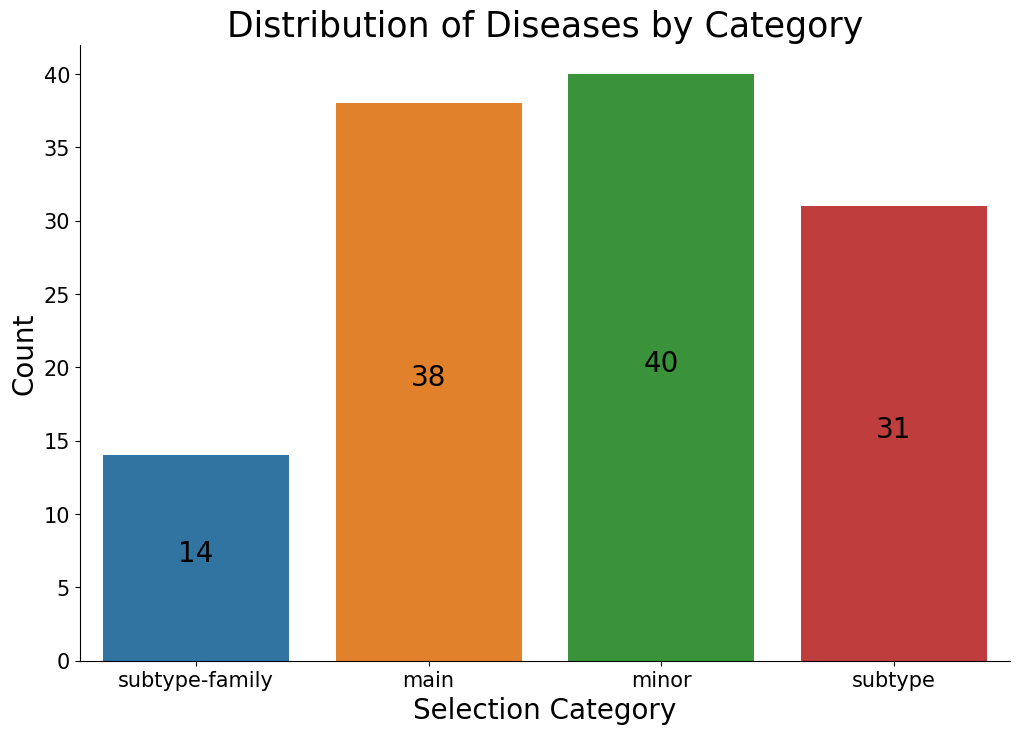

In [35]:
fig, ax = plt.subplots(figsize=(12, 8))

c = sns.countplot(csv, x="selection")

for container in c.containers:
    labels = [f'{height:.0f}' if height > 0 else '' for height in container.datavalues]
    c.bar_label(container, labels=labels, label_type="center", padding=3, fontsize = 20)
    
sns.despine()

plt.xticks(fontsize=15) 
plt.yticks(fontsize=15) 
plt.xlabel('Selection Category', fontsize=20) 
plt.ylabel('Count', fontsize=20)  
plt.title('Distribution of Diseases by Category', fontsize=25) 


Text(0.5, 1.0, 'Selection Category of Diseases')

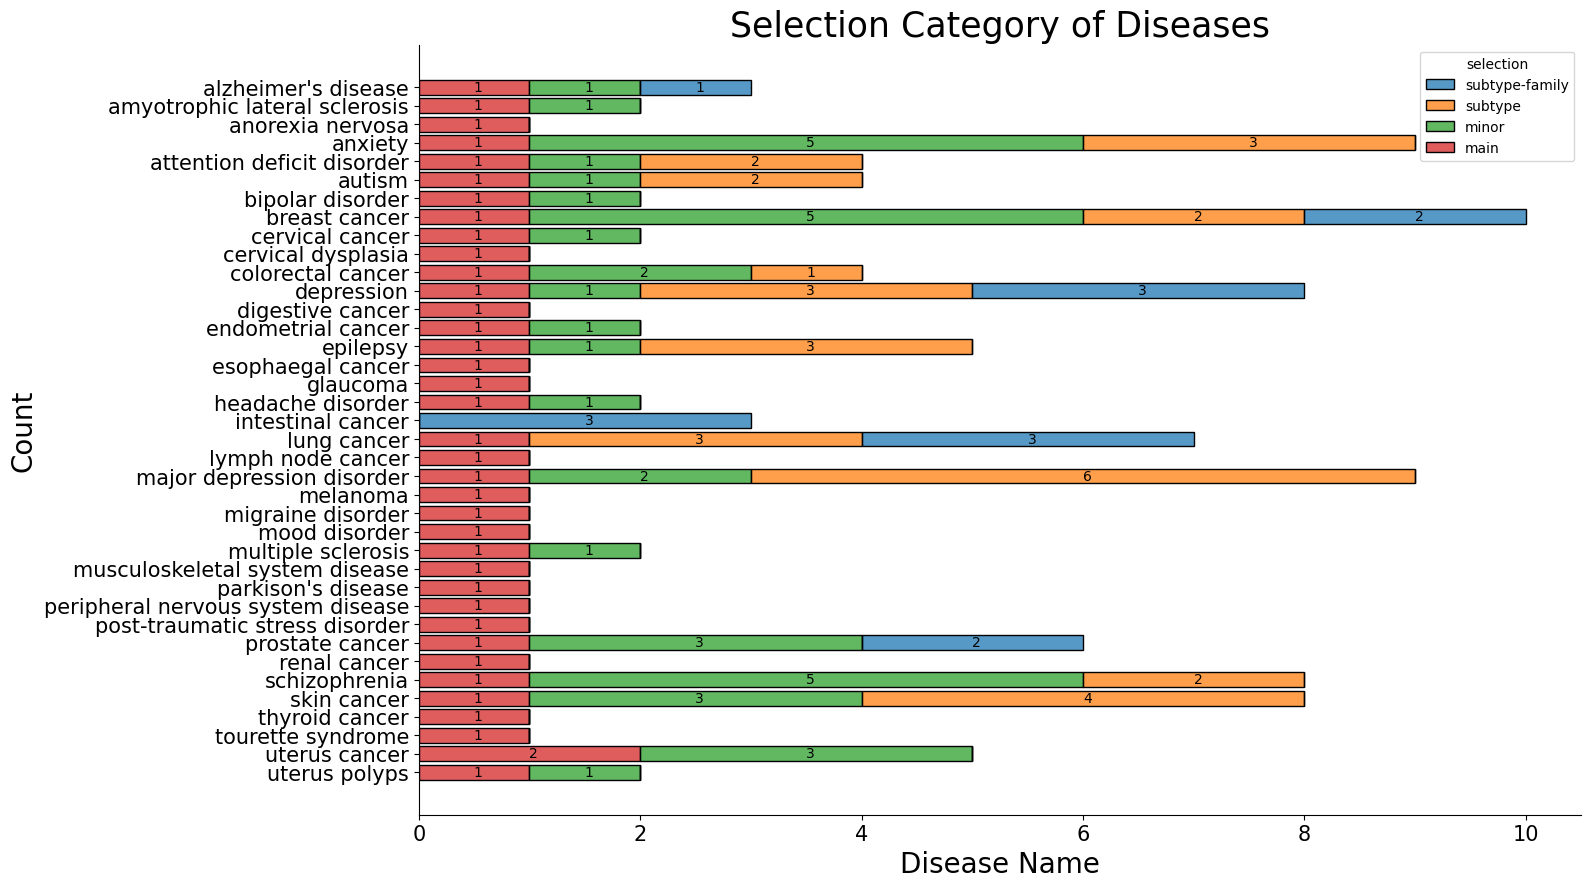

In [37]:
fig, ax = plt.subplots(figsize=(15, 10))
a = sns.histplot(csv, y="disease", hue="selection", multiple="stack", hue_order=["subtype-family","subtype","minor","main"], binwidth=1, ax=ax, shrink=.8)
# plt.xticks(rotation=0)

# Adding labels for each container
for container in a.containers:
    labels = [f'{height:.0f}' if height > 0 else '' for height in container.datavalues]
    a.bar_label(container, labels=labels, label_type="center", padding=3, fontsize=10)

sns.despine()

plt.xticks(fontsize=15) 
plt.yticks(fontsize=15) 
plt.xlabel('Disease Name', fontsize=20) 
plt.ylabel('Count', fontsize=20)  
plt.title('Selection Category of Diseases', fontsize=25) 

In [50]:
csv['disease'] = pd.Categorical(csv['disease'], categories=sorted_disease_order, ordered=True)
csv = csv.sort_values('disease')

Text(0.5, 1.0, 'Selection Category of Diseases')

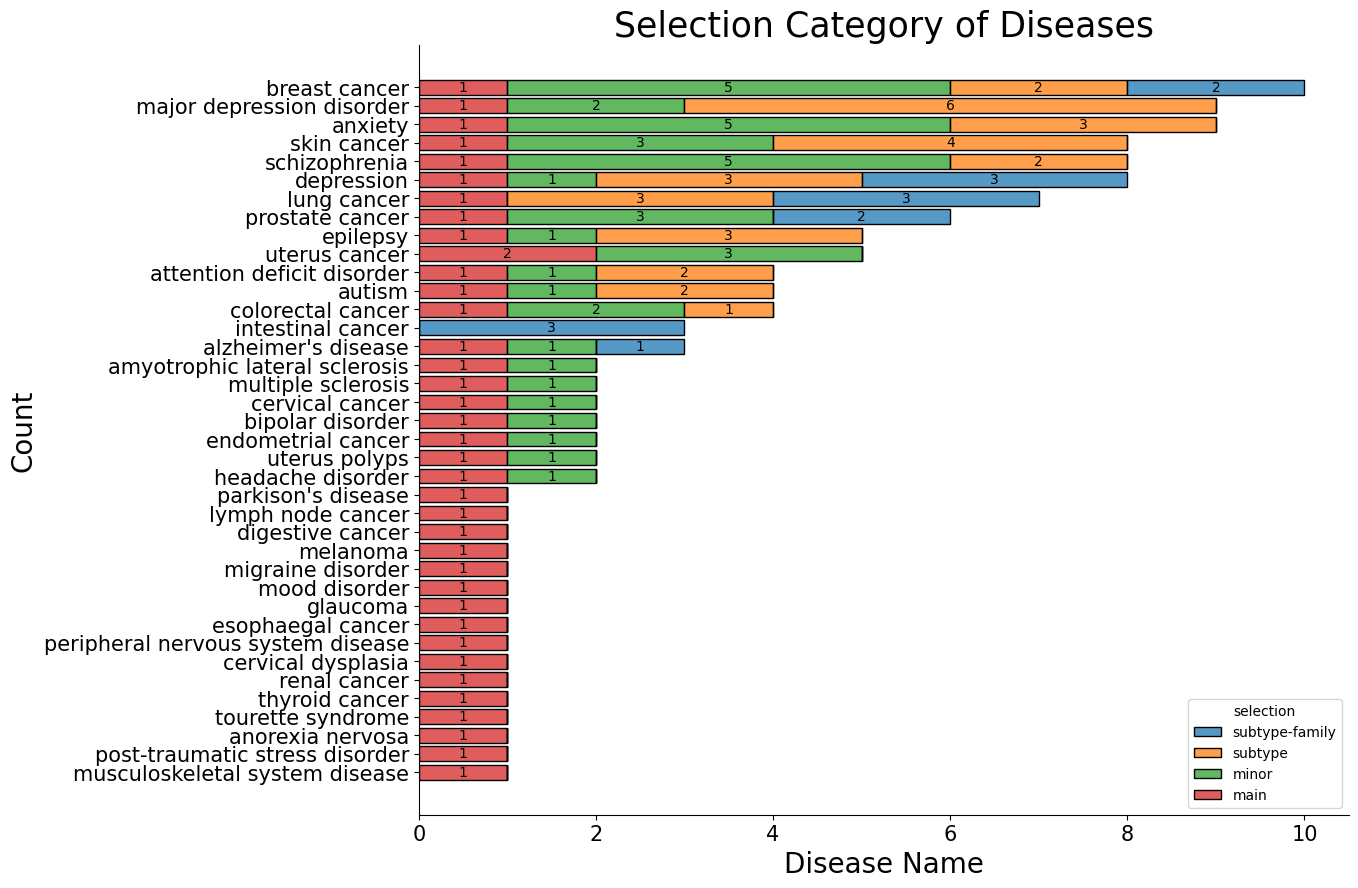

In [51]:
fig, ax = plt.subplots(figsize=(12, 10))
a = sns.histplot(csv, y='disease', hue='selection', multiple='stack', hue_order=['subtype-family', 'subtype', 'minor', 'main'], binwidth=1, ax=ax, shrink=0.8)

# Adding labels for each container
for container in a.containers:
    heights = container.datavalues
    for bar, height in zip(container.patches, heights):
        if height > 0:
            width = bar.get_width()
            x = bar.get_x() + width / 2
            y = bar.get_y() + bar.get_height() / 2
            ax.text(x, y, f'{int(height)}', ha='center', va='center', color='black', fontsize=10)

sns.despine()

plt.xticks(fontsize=15) 
plt.yticks(fontsize=15) 
plt.xlabel('Disease Name', fontsize=20) 
plt.ylabel('Count', fontsize=20)  
plt.title('Selection Category of Diseases', fontsize=25) 


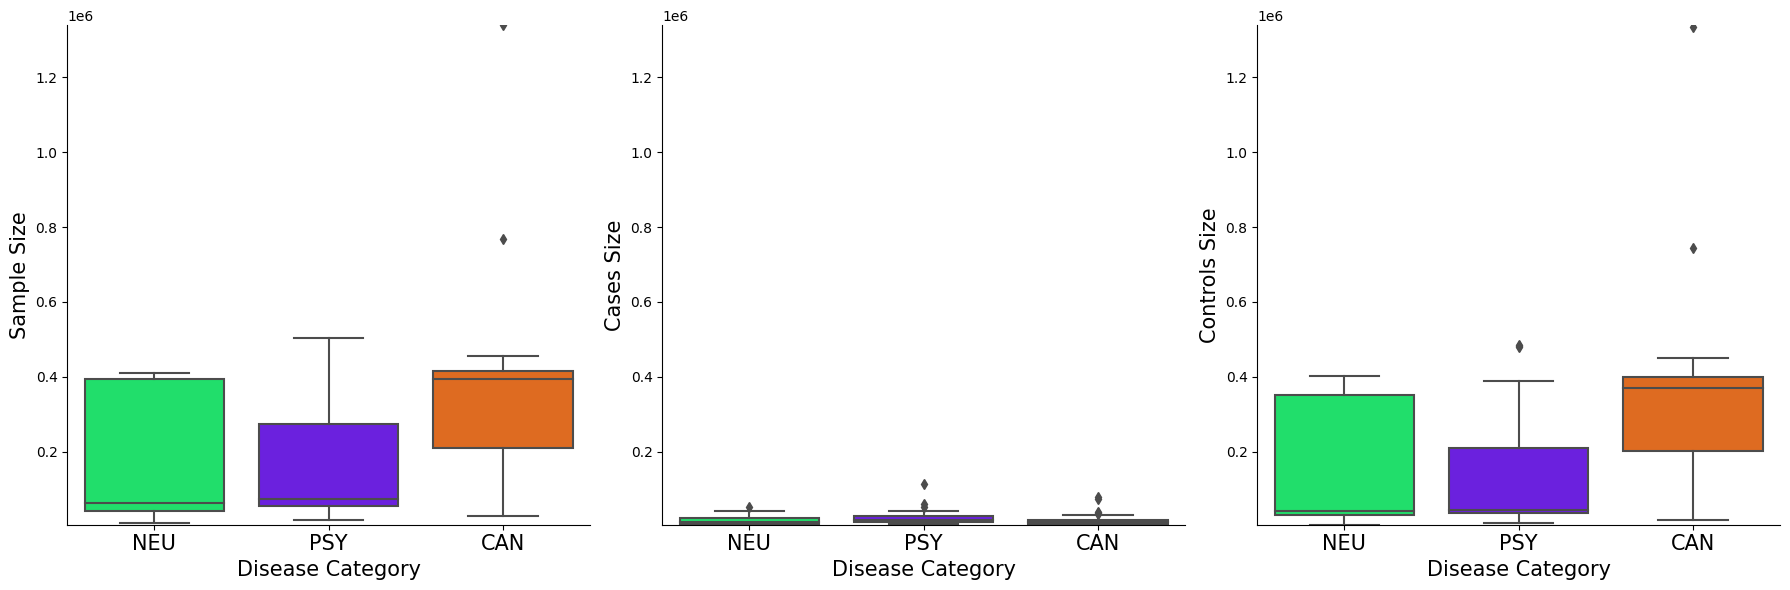

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Determine the global y-axis limits
y_min = min(csv[['N_num', 'Nca_val', 'Nco_val']].min())
y_max = max(csv[['N_num', 'Nca_val', 'Nco_val']].max())

# Boxplot for N_num
sns.boxplot(x='type', y='N_num', data=csv, ax=axes[0], palette=type_palette)
# axes[0].set_title('Sample Size by Disease Category', fontsize=20)
axes[0].set_xlabel('Disease Category', fontsize=15)
axes[0].set_ylabel('Sample Size', fontsize=15)
axes[0].set_ylim(y_min, y_max)

# Boxplot for Nca_val
sns.boxplot(x='type', y='Nca_val', data=csv, ax=axes[1], palette=type_palette)
# axes[1].set_title('Cases Size by Disease Category', fontsize=20)
axes[1].set_xlabel('Disease Category', fontsize=15)
axes[1].set_ylabel('Cases Size', fontsize=15)
axes[1].set_ylim(y_min, y_max)

# Boxplot for Nco_val
sns.boxplot(x='type', y='Nco_val', data=csv, ax=axes[2], palette=type_palette)
# axes[2].set_title('Cases Size by Disease Category', fontsize=20)
axes[2].set_xlabel('Disease Category', fontsize=15)
axes[2].set_ylabel('Controls Size', fontsize=15)
axes[2].set_ylim(y_min, y_max)

# Increase x-tick label sizes
for ax in axes:
    ax.tick_params(axis='x', labelsize=15)
    ax.tick_params(axis='y', labelsize=10)

# Adjust layout for better readability and remove spines
plt.tight_layout()
sns.despine()
plt.show()



Text(0, 0.5, 'Number of Controls (Nco_val)')

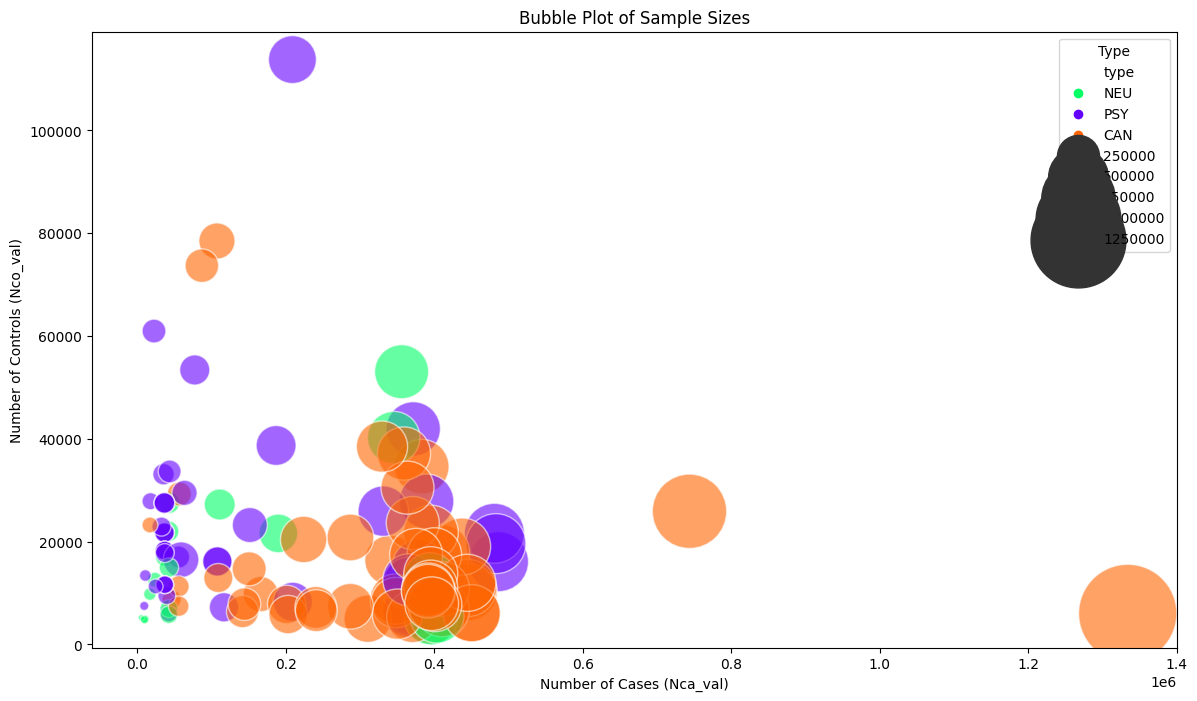

In [40]:
plt.figure(figsize=(14, 8))
bubble_plot = sns.scatterplot(
    data=csv, 
    x="Nco_val", 
    y="Nca_val", 
    size="N_num", 
    sizes=(20, 5000),  # Adjust these values to scale bubbles appropriately
    alpha=0.6,
    hue="type",
    legend="brief",
	palette=type_palette
)

handles, labels = bubble_plot.get_legend_handles_labels()
new_handles = [h for h, l in zip(handles, labels) if l != 'N_num']
new_labels = [l for l in labels if l != 'N_num']
plt.legend(handles=new_handles, labels=new_labels, title='Type')

plt.title('Bubble Plot of Sample Sizes')
plt.xlabel('Number of Cases (Nca_val)')
plt.ylabel('Number of Controls (Nco_val)')



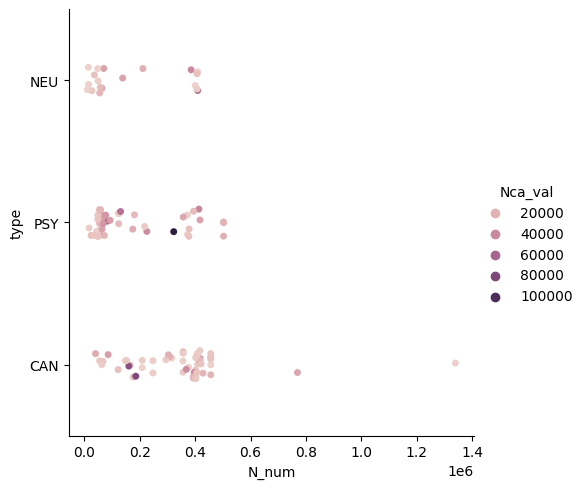

In [14]:
sns.catplot(data=csv, y="type", x="N_num", hue="Nca_val")

In [15]:
can = csv[csv["type"]=="CAN"]
psy = csv[csv["type"]=="PSY"]
neu = csv[csv["type"]=="NEU"]

Text(0.5, 1.0, 'Total Size distribution segregated by Case size')

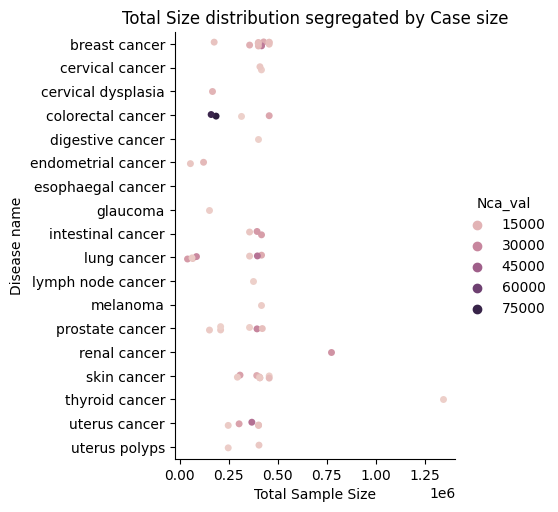

In [16]:
sns.catplot(data=can, y="disease", x="N_num", hue="Nca_val")
plt.xlabel('Total Sample Size')
plt.ylabel('Disease name')
plt.title('Total Size distribution segregated by Case size')

Text(0.5, 1.0, 'Total Size distribution segregated by Case size')

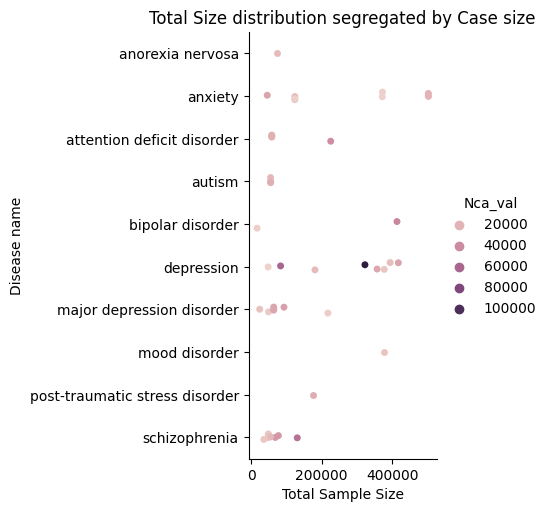

In [17]:
sns.catplot(data=psy, y="disease", x="N_num", hue="Nca_val")
plt.xlabel('Total Sample Size')
plt.ylabel('Disease name')
plt.title('Total Size distribution segregated by Case size')

Text(0.5, 1.0, 'Total Size distribution segregated by Case size')

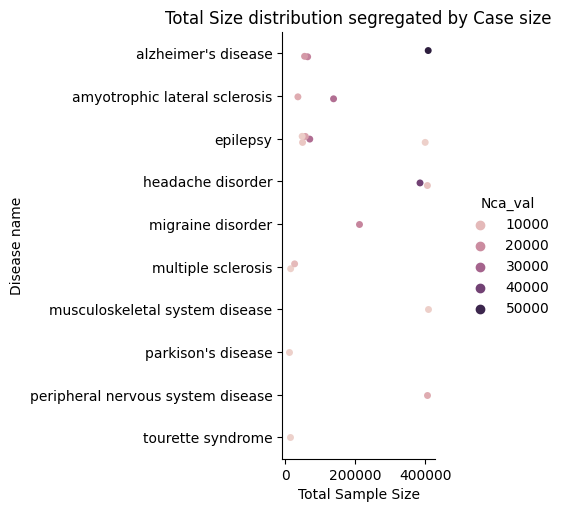

In [18]:
sns.catplot(data=neu, y="disease", x="N_num", hue="Nca_val")
plt.xlabel('Total Sample Size')
plt.ylabel('Disease name')
plt.title('Total Size distribution segregated by Case size')

In [19]:
csv['combination'] = (csv['z'].notnull().astype(int).astype(str) + 
                      csv['b'].notnull().astype(int).astype(str) + 
                      csv['OR'].notnull().astype(int).astype(str))

# Binary representation to see whether the column has a value according to the combination
combination_labels = {
    '100': 'Z-SCORE',
    '010': 'BETA',
    '001': 'ODDS RATIO',
    '110': 'Z-SCORE AND BETA',
    '101': 'Z-SCORE AND ODDS RATIO',
    '011': 'BETA AND ODDS RATIO',
    '111': 'ALL THREE',
	'000': 'NONE'
}
csv['combination'] = csv['combination'].map(combination_labels)

combination_counts = csv['combination'].value_counts().reset_index()
combination_counts.columns = ['Combination', 'Count']

Text(0.5, 1.0, 'Distribution of Studies by Presence of z, b, OR')

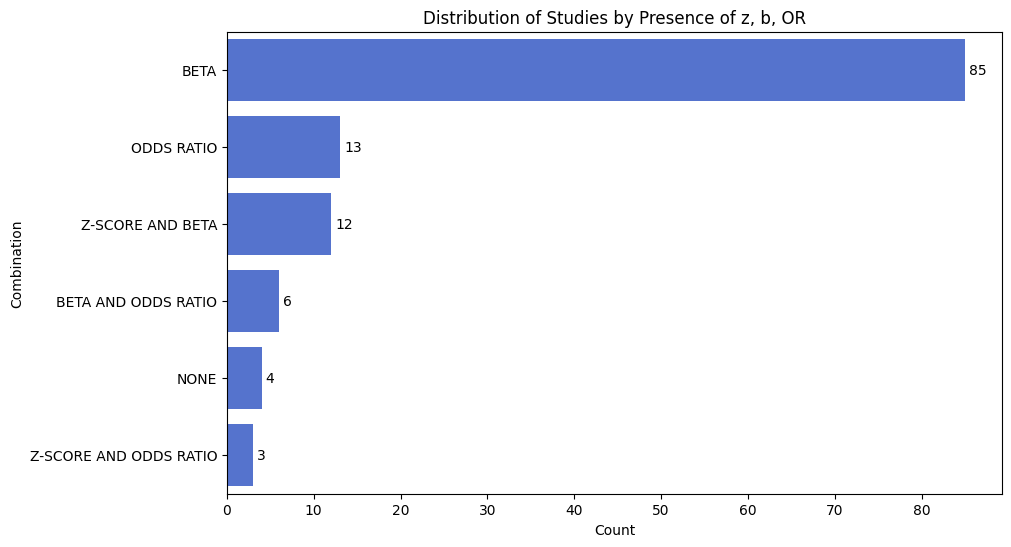

In [20]:
plt.figure(figsize=(10, 6))
a = sns.barplot(x='Count', y='Combination', data=combination_counts, color="royalblue")

for container in a.containers:
    labels = [f'{height:.0f}' if height > 0 else '' for height in container.datavalues]
    a.bar_label(container, labels=labels, label_type="edge", padding=3)
    
plt.xlabel('Count')
plt.ylabel('Combination')
plt.title('Distribution of Studies by Presence of z, b, OR')


In [48]:
se_count = csv["se"].fillna("Missing").value_counts()
se_count = se_count
se_count

standard_error    76
sebeta            19
SE                15
Missing            6
se                 2
StandardError      2
StdErr             1
LOG(OR)_SE         1
STDERR             1
Name: se, dtype: int64

Text(0.5, 1.0, 'SE')

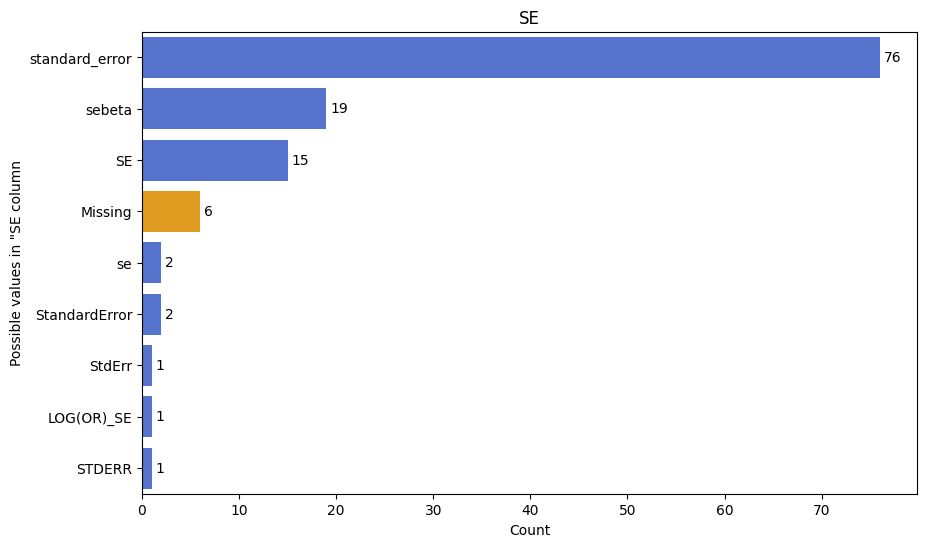

In [55]:
clrs = ['orange' if (x == "Missing") else 'royalblue' for x in se_count.index]

plt.figure(figsize=(10, 6)) 
a = sns.barplot(y=se_count.index, x=se_count.values, palette=clrs) 

for container in a.containers: 
    labels = [f'{height:.0f}' if height > 0 else '' for height in container.datavalues] 
    a.bar_label(container, labels=labels, label_type="edge", padding=3)

plt.xlabel('Count')
plt.ylabel('Possible values in "SE column')
plt.title('SE')
